## 0. Create the Pro/Anti Master Csvs

In [1]:
import os
import json
from tqdm import tqdm
import numpy as np
import pandas as pd

np.random.seed(42)


# ----------------------------
# Load comments+analysis text from all csv files
# ----------------------------sx
file_dir = "../csv_files/finegrained_analysis"
file_dir_2 = "../csv_files"

total_df_pro = pd.DataFrame()

for filename in os.listdir(file_dir):
    # concat all csv files within the pro-armenian alignment
    if filename.endswith("_output.csv"):
        filename_2 = filename.replace("_finegrained", "")
        file_path = os.path.join(file_dir, filename)
        file_path_2 = os.path.join(file_dir_2, filename_2)
        df = pd.read_csv(file_path, encoding="utf-8")
        df = df[df["finegrained_judgment"] == "Pro-Armenian"] # Filter to only "Pro-Armenian" judgments
        df_2 = pd.read_csv(file_path_2, encoding="utf-8")
        df["Timestamp"] = df_2["Timestamp"]
        df["User"] = df_2["User"]
        # rearrange the colums to be User, Timestamp, finegrained_judgment, finegrained_analysis, weaponization_technique, reduced_weaponization_technique
        df = df[["User", "Timestamp", "source", "finegrained_judgment", "finegrained_analysis"]]
        total_df_pro = pd.concat([total_df_pro, df], ignore_index=True)
        


In [30]:
save_dir = "../other_outputs/finegrained/pro_armenian_total.csv"

total_df_pro.to_csv(save_dir, index=False, encoding="utf-8")

In [2]:
import os
import json
from tqdm import tqdm
import numpy as np
import pandas as pd

np.random.seed(42)


# ----------------------------
# Load comments+analysis text from all csv files
# ----------------------------sx
file_dir = "../csv_files/finegrained_analysis"
file_dir_2 = "../csv_files"

total_df_anti = pd.DataFrame()

for filename in os.listdir(file_dir):
    # concat all csv files within the pro-armenian alignment
    if filename.endswith("_output.csv"):
        filename_2 = filename.replace("_finegrained", "")
        file_path = os.path.join(file_dir, filename)
        file_path_2 = os.path.join(file_dir_2, filename_2)
        df = pd.read_csv(file_path, encoding="utf-8")
        df = df[df["finegrained_judgment"] == "Anti-Armenian"] # Filter to only "Pro-Armenian" judgments
        df_2 = pd.read_csv(file_path_2, encoding="utf-8")
        df["Timestamp"] = df_2["Timestamp"]
        df["User"] = df_2["User"]
        # rearrange the colums to be User, Timestamp, finegrained_judgment, finegrained_analysis, weaponization_technique, reduced_weaponization_technique
        df = df[["User", "Timestamp", "source", "finegrained_judgment", "finegrained_analysis"]]
        total_df_anti = pd.concat([total_df_anti, df], ignore_index=True)
        


In [32]:
save_dir = "../other_outputs/finegrained/anti_armenian_total.csv"

total_df_anti.to_csv(save_dir, index=False, encoding="utf-8")

In [3]:
import os
import json
from tqdm import tqdm
import numpy as np
import pandas as pd

np.random.seed(42)


# ----------------------------
# Load comments+analysis text from all csv files
# ----------------------------sx
file_dir = "../csv_files"

total_df_everyone_else = pd.DataFrame()

for filename in os.listdir(file_dir):
    # concat all csv files within the pro-armenian alignment
    if filename.endswith("_output.csv"):
        file_path = os.path.join(file_dir, filename)
        df = pd.read_csv(file_path, encoding="utf-8")
        df = df[df["Judgment"] == "Not Weaponised"] # Filter to only "Pro-Armenian" judgments
        # rearrange the colums to be User, Timestamp, finegrained_judgment, finegrained_analysis, weaponization_technique, reduced_weaponization_technique
        df = df[["User", "Timestamp", "Source", "Judgment", "Analysis"]]
        total_df_everyone_else = pd.concat([total_df_everyone_else, df], ignore_index=True)

# 0. Basic Year Analysis etc

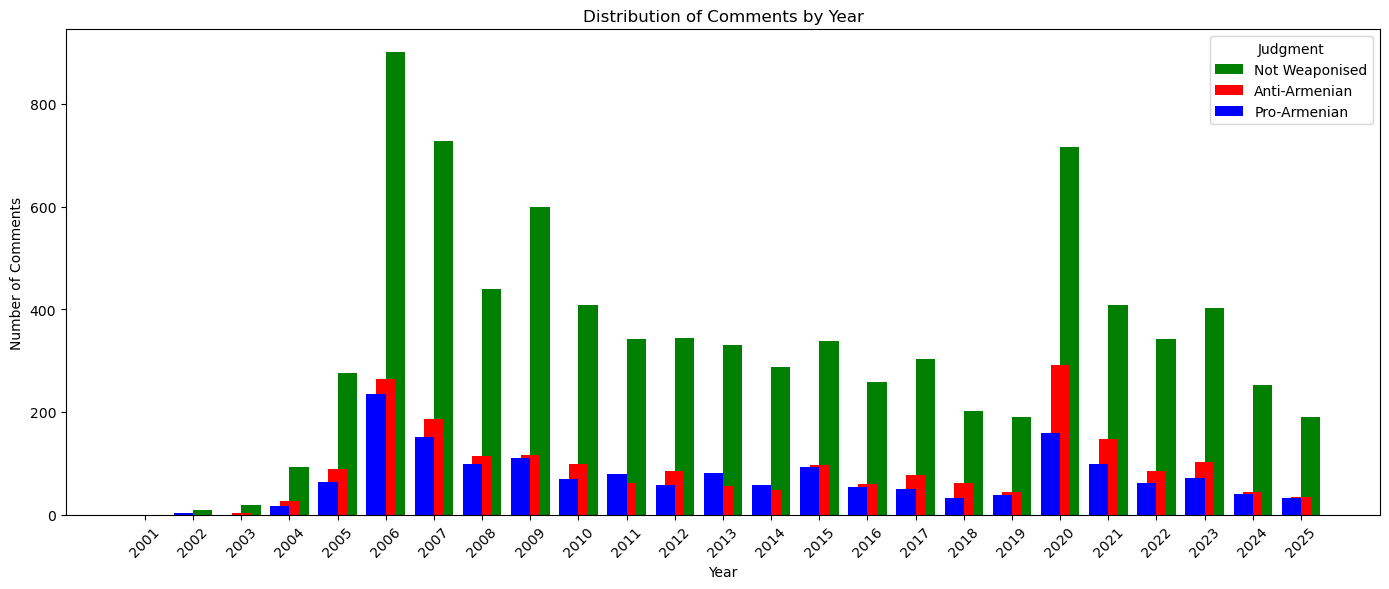

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
total_df_pro["Label"] = "Pro-Armenian"
total_df_anti["Label"] = "Anti-Armenian"
total_df_everyone_else["Label"] = "Not Weaponised"
# rename total_df_pro and _anti's columns to be consistent
total_df_pro.columns = ["User", "Timestamp", "Source", "Judgment", "Analysis", "Label"]
total_df_anti.columns = ["User", "Timestamp", "Source", "Judgment", "Analysis", "Label"]
combined_df = pd.concat([total_df_pro, total_df_anti, total_df_everyone_else], ignore_index=True)
combined_df["Year"] = pd.to_datetime(combined_df["Timestamp"]).dt.year

# Count per group per year
count_df = combined_df.groupby(["Year", "Label"]).size().unstack(fill_value=0)

# Ensure all years are present
all_years = list(range(2001, 2026))
count_df = count_df.reindex(all_years, fill_value=0)

# Plotting
x = np.arange(len(all_years))  # numeric x positions
width = 0.4  # width of each bar

plt.figure(figsize=(14, 6))

plt.bar(x + width/2, count_df.get("Not Weaponised", 0), width=width, label="Not Weaponised", color='green')
plt.bar(x, count_df.get("Anti-Armenian", 0), width=width, label="Anti-Armenian", color='red')
plt.bar(x - width/2, count_df.get("Pro-Armenian", 0), width=width, label="Pro-Armenian", color='blue')


plt.xticks(x, all_years, rotation=45)
plt.xlabel("Year")
plt.ylabel("Number of Comments")
plt.title("Distribution of Comments by Year")
plt.legend(title="Judgment")
plt.tight_layout()
plt.show()



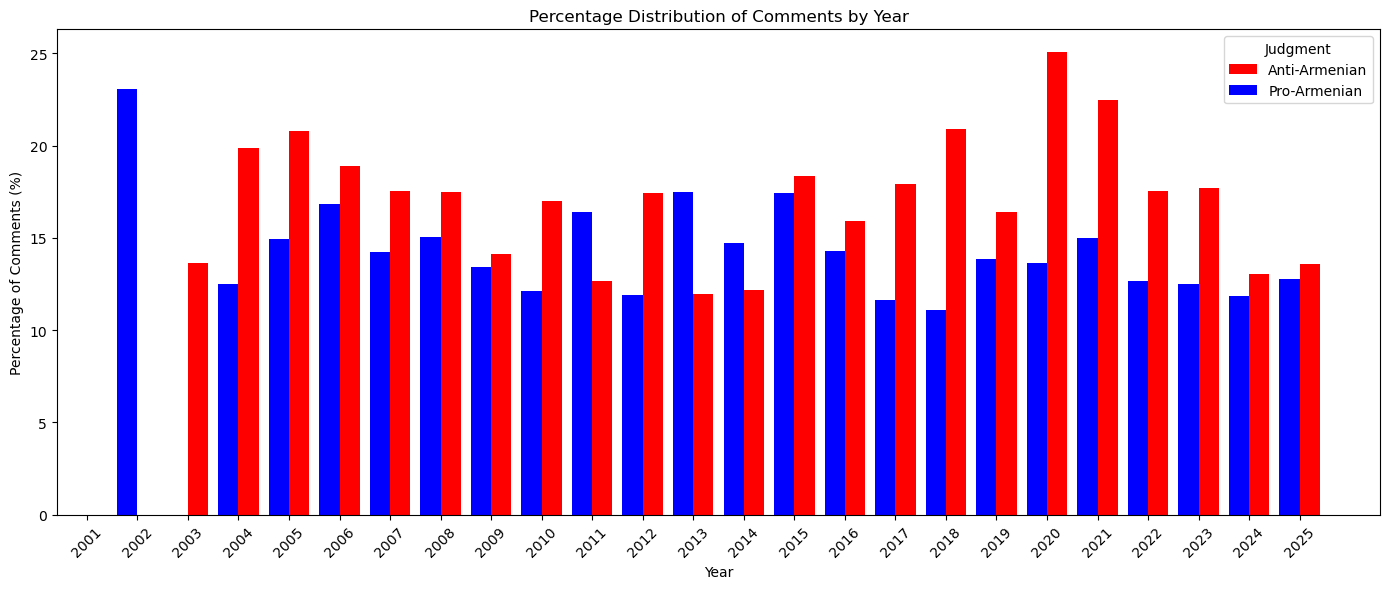

In [4]:
# plot a similar plot but with the percentage of both pro-armenian and anti-armenian among total edits (the sum of all three) per year
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
total_df_pro["Label"] = "Pro-Armenian"
total_df_anti["Label"] = "Anti-Armenian"
total_df_everyone_else["Label"] = "Not Weaponised"
# rename total_df_pro and _anti's columns to be consistent
total_df_pro.columns = ["User", "Timestamp", "Source", "Judgment", "Analysis", "Label"]
total_df_anti.columns = ["User", "Timestamp", "Source", "Judgment", "Analysis", "Label"]
combined_df = pd.concat([total_df_pro, total_df_anti, total_df_everyone_else], ignore_index=True)
combined_df["Year"] = pd.to_datetime(combined_df["Timestamp"]).dt.year
# Count per group per year
count_df = combined_df.groupby(["Year", "Label"]).size().unstack(fill_value=0)
# Ensure all years are present
all_years = list(range(2001, 2026))
count_df = count_df.reindex(all_years, fill_value=0)
# Calculate percentages
count_df_percent = count_df.div(count_df.sum(axis=1), axis=0) * 100
# Plotting
x = np.arange(len(all_years))  # numeric x positions
width = 0.4  # width of each bar
plt.figure(figsize=(14, 6))
#plt.bar(x + width/2, count_df_percent.get("Not Weaponised", 0), width=width, label="Not Weaponised", color='green')
plt.bar(x + width/2, count_df_percent.get("Anti-Armenian", 0), width=width, label="Anti-Armenian", color='red')
plt.bar(x - width/2, count_df_percent.get("Pro-Armenian", 0), width=width, label="Pro-Armenian", color='blue')
plt.xticks(x, all_years, rotation=45)
plt.xlabel("Year")
plt.ylabel("Percentage of Comments (%)")
plt.title("Percentage Distribution of Comments by Year")
plt.legend(title="Judgment")
plt.tight_layout()
plt.show()


In [12]:
total_df_pro["Timestamp"].str.contains("2006", na=None).isna().sum()

np.int64(3)

In [5]:
# count the source distribution of pro-armenian and anti-armenian comments in the year 2006

source_counts_pro_2006 = total_df_pro[total_df_pro["Timestamp"].str.contains("2006", na=False)]["Source"].value_counts()
source_counts_anti_2006 = total_df_anti[total_df_anti["Timestamp"].str.contains("2006", na=False)]["Source"].value_counts()
source_counts_pro_2006_percentage = source_counts_pro_2006 / source_counts_pro_2006.sum() * 100
source_counts_anti_2006_percentage = source_counts_anti_2006 / source_counts_anti_2006.sum() * 100

source_counts_pro_2020 = total_df_pro[total_df_pro["Timestamp"].str.contains("2020", na=False)]["Source"].value_counts()
source_counts_anti_2020 = total_df_anti[total_df_anti["Timestamp"].str.contains("2020", na=False)]["Source"].value_counts()
source_counts_pro_2020_percentage = source_counts_pro_2020 / source_counts_pro_2020.sum() * 100
source_counts_anti_2020_percentage = source_counts_anti_2020 / source_counts_anti_2020.sum() * 100

In [14]:
source_counts_pro_2006

Source
Armenian genocide_subsampled                                         73
Nagorno-Karabakh_subsampled                                          31
Armenia_subsampled                                                   19
Nakhchivan Autonomous Republic_subsampled                            17
First Nagorno-Karabakh War_subsampled                                12
History_of_Nagorno-Karabakh_subsampled                                9
Urartu_subsampled                                                     7
History_of_Armenia_subsampled                                         6
Armenians_subsampled                                                  6
Artsakh (historical province)_subsampled                              5
Shusha_subsampled                                                     5
Armenian_Revolutionary_Federation_subsampled                          5
Armenian_diaspora_subsampled                                          4
Lavash_subsampled                                        

In [11]:
source_counts_anti_2020_percentage

Source
Second Nagorno-Karabakh War_subsampled             58.219178
Republic of Artsakh_subsampled                      7.534247
Armenian genocide_subsampled                        4.452055
Shusha_subsampled                                   3.767123
Dolma_subsampled                                    3.424658
Nagorno-Karabakh_conflict_subsampled                3.424658
History_of_Nagorno-Karabakh_subsampled              2.397260
First Nagorno-Karabakh War_subsampled               2.054795
Armenian_highlands_subsampled                       1.712329
Armenian_genocide_recognition_subsampled            1.369863
Artsakh (historical province)_subsampled            1.369863
Lavash_subsampled                                   1.369863
Armenia_subsampled                                  1.027397
Victory_Day_(9_May)_subsampled                      1.027397
Karabakh_subsampled                                 1.027397
Nagorno-Karabakh_subsampled                         0.684932
Urartu_subsampled

In [15]:
source_counts_anti_2006

Source
Armenian genocide_subsampled                       75
Nagorno-Karabakh_subsampled                        36
Nakhchivan Autonomous Republic_subsampled          27
Armenia_subsampled                                 16
First Nagorno-Karabakh War_subsampled              16
History_of_Nagorno-Karabakh_subsampled             12
Shusha_subsampled                                  11
History_of_Armenia_subsampled                       9
Kars_subsampled                                     6
Adana_subsampled                                    6
Mount_Ararat_subsampled                             4
Armenians_subsampled                                4
Armed_Forces_of_Armenia_subsampled                  4
Dolma_subsampled                                    4
Armenian_Revolutionary_Federation_subsampled        3
Yerevan_subsampled                                  3
Artsakh (historical province)_subsampled            3
Iğdır_subsampled                                    3
Urartu_subsampled    

In [8]:
source_counts_pro_2020

Source
Second Nagorno-Karabakh War_subsampled                      64
Republic of Artsakh_subsampled                               9
Shusha_subsampled                                            8
Nagorno-Karabakh_conflict_subsampled                         7
Armenian genocide_subsampled                                 6
Armenian_genocide_recognition_subsampled                     6
First Nagorno-Karabakh War_subsampled                        6
Foreign_relations_of_Armenia_subsampled                      5
History_of_Nagorno-Karabakh_subsampled                       4
Adana_subsampled                                             4
Yerevan_subsampled                                           4
Karabakh_subsampled                                          3
Kars_subsampled                                              3
Lavash_subsampled                                            3
Urartu_subsampled                                            3
Dolma_subsampled                                

In [18]:
source_counts_anti_2020

Source
Second Nagorno-Karabakh War_subsampled             170
Republic of Artsakh_subsampled                      22
Armenian genocide_subsampled                        13
Shusha_subsampled                                   11
Dolma_subsampled                                    10
Nagorno-Karabakh_conflict_subsampled                10
History_of_Nagorno-Karabakh_subsampled               7
First Nagorno-Karabakh War_subsampled                6
Armenian_highlands_subsampled                        5
Armenian_genocide_recognition_subsampled             4
Artsakh (historical province)_subsampled             4
Lavash_subsampled                                    4
Armenia_subsampled                                   3
Victory_Day_(9_May)_subsampled                       3
Karabakh_subsampled                                  3
Nagorno-Karabakh_subsampled                          2
Urartu_subsampled                                    2
Kars_subsampled                                      2
Arm

# 1. Weaponization Category Mapping and Analysis

In [24]:
len(df_anti)

2199

In [17]:
import pandas as pd

# load pro- and anti-armenian weaponization categorization results


df_pro = pd.read_csv("../other_outputs/finegrained/weaponization_analysis/pro-armenian_all_revisions_with_weaponization_techniques.csv", encoding="utf-8")
df_anti = pd.read_csv("../other_outputs/finegrained/weaponization_analysis/anti-armenian_all_revisions_with_weaponization_techniques.csv", encoding="utf-8")

In [12]:
# for df_pro, standardize "Selectively Insertion" and "SelectivOmission" to "Selective Insertion" and "Selective Omission" respectively
df_pro["weaponization_technique"] = df_pro["weaponization_technique"].replace({"Selectively Insertion": "Selective Insertion", "SelectivOmission": "Selective Omission"})

In [18]:
# for df_anti, standardize "Selective Deletion" to "Selective Omission" 
df_anti["weaponization_technique"] = df_anti["weaponization_technique"].replace({"Selective Deletion": "Selective Omission"})

In [19]:
# count the percentage of each weaponization technique in pro-armenian revisions under the "weaponization_technique" column
pro_weaponization_counts = df_pro["weaponization_technique"].value_counts(normalize=True) * 100
anti_weaponization_counts = df_anti["weaponization_technique"].value_counts(normalize=True) * 100

In [20]:
pro_weaponization_counts_raw = df_pro["weaponization_technique"].value_counts()
anti_weaponization_counts_raw = df_anti["weaponization_technique"].value_counts()

In [15]:
pro_weaponization_counts_raw

weaponization_technique
Terminology Biasing             989
Glorification & Vilification    254
Selective Omission              237
Selective Insertion             236
Source Biasing                   15
Tag Manipulation                 12
Timeline Rewriting               11
Euphemism and Doublespeak         5
Citation Deletion                 2
Name: count, dtype: int64

In [21]:
anti_weaponization_counts_raw

weaponization_technique
Terminology Biasing             1006
Selective Omission               870
Glorification & Vilification     183
Selective Insertion               65
Euphemism and Doublespeak         31
Tag Manipulation                  29
Source Biasing                     9
Timeline Rewriting                 3
Citation Deletion                  2
Citation Washing                   1
Name: count, dtype: int64

In [16]:
pro_weaponization_counts

weaponization_technique
Terminology Biasing             56.161272
Glorification & Vilification    14.423623
Selective Omission              13.458262
Selective Insertion             13.401476
Source Biasing                   0.851789
Tag Manipulation                 0.681431
Timeline Rewriting               0.624645
Euphemism and Doublespeak        0.283930
Citation Deletion                0.113572
Name: proportion, dtype: float64

In [22]:
anti_weaponization_counts

weaponization_technique
Terminology Biasing             45.748067
Selective Omission              39.563438
Glorification & Vilification     8.321965
Selective Insertion              2.955889
Euphemism and Doublespeak        1.409732
Tag Manipulation                 1.318781
Source Biasing                   0.409277
Timeline Rewriting               0.136426
Citation Deletion                0.090950
Citation Washing                 0.045475
Name: proportion, dtype: float64

In [7]:
# simplication mapping
category_mapper = {
    "Terminology Biasing": "Linguistic Manipulation",
    "Euphemism and Doublespeak": "Linguistic Manipulation",
    "Selective Omission": "Factual Manipulation",
    "Selective Insertion": "Factual Manipulation",
    "Timeline Rewriting": "Factual Manipulation",
    "Source Biasing": "Factual Manipulation",
    "Citation Washing": "Factual Manipulation",
    "Citation Deletion": "Factual Manipulation",
    "Tag Manipulation": "Factual Manipulation",
    "Glorification & Vilification": "Linguistic Manipulation",
}

df_pro["reduced_weaponization_technique"] = df_pro["weaponization_technique"].map(category_mapper)
df_anti["reduced_weaponization_technique"] = df_anti["weaponization_technique"].map(category_mapper)

# count those too
pro_reduced_counts = df_pro["reduced_weaponization_technique"].value_counts(normalize=True) * 100
anti_reduced_counts = df_anti["reduced_weaponization_technique"].value_counts(normalize=True) * 100

In [4]:
len(demo)

183

In [6]:
demo = df_anti[df_anti["weaponization_technique"] == "Glorification & Vilification"]
for row in demo.itertuples():
    print(row.finegrained_analysis)
    print("-----")

Record 293 (Version: N/A):
**Judgment:** Anti-Armenian

**Analysis:** The revision contains several phrases that significantly alter the tone and narrative regarding Armenians, portraying them in a negative light. For example, the addition of "These units are hold responsible from killing civil Turks and destroying entire Turkish villages close to Russian boarders" directly accuses Armenian forces of aggression, which shifts the focus from the historical context of victimization to one of culpability. Furthermore, the phrase "accusation of provoking civil Armenians in big cities to revolt against the empire" suggests that Armenians were instigators of violence, further demonizing them and implying that they were responsible for their own suffering. The term "cleaning the Lands of Armenia from Turkish civils" evokes a narrative of ethnic cleansing, which is a stark departure from the original text that presented a more neutral account of historical events. Overall, these changes reflect

In [25]:
len(df_pro)

1761

In [26]:
len(df_anti)

2199

In [8]:
pro_reduced_counts

reduced_weaponization_technique
Linguistic Manipulation    70.949403
Factual Manipulation       29.050597
Name: proportion, dtype: float64

In [9]:
anti_reduced_counts

reduced_weaponization_technique
Linguistic Manipulation    55.505005
Factual Manipulation       44.494995
Name: proportion, dtype: float64